# Project 1 · Task 8 — Empirical vs theoretical lifetime distribution

The CTMC lifetime follows a continuous phase-type distribution with CDF $F_T(t)=1-p_0\exp(Q_s t)\mathbf 1$, where $Q_s$ is $Q$ without the death row/column. We simulate 1000 lifetimes (embedded chain, as in Task 7) and compare the empirical CDF to $F_T$ with a Kolmogorov–Smirnov test.

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.stats import kstwobign

rng = np.random.default_rng(2026)
plt.rcParams["figure.figsize"] = (10, 4)

# Transition-rate matrix Q, one time unit = one month. States (0-indexed): 0 post-surgery, 1 local recurrence, 2 distant metastasis, 3 both, 4 death.
Q = np.array([
    [-0.0085, 0.005,  0.0025, 0.0,   0.001],
    [ 0.0,   -0.014,  0.005,  0.004, 0.005],
    [ 0.0,    0.0,   -0.008,  0.003, 0.005],
    [ 0.0,    0.0,    0.0,   -0.009, 0.009],
    [ 0.0,    0.0,    0.0,    0.0,   0.0  ]])
DEATH = 4

Qs = Q[:4, :4] # sub-generator: Q without the death row/column
p0 = np.array([1.0, 0, 0, 0])  # initial distribution over the transient states
ones = np.ones(4)


def F_T(t):
    """Theoretical lifetime CDF (continuous phase-type): F(t) = 1 - p0 . expm(Qs t) . 1."""
    t = np.atleast_1d(np.asarray(t, float))
    return np.array([1.0 - p0 @ expm(Qs * ti) @ ones for ti in t])

In [ ]:
def simulate_lifetime(start=0):
    """Lifetime until death via the embedded chain (sojourn Exp(-q_ii), then a jump)."""
    t, s = 0.0, start
    while s != DEATH:
        rate = -Q[s, s]
        t += -np.log(rng.random()) / rate # sojourn ~ Exp(rate): inverse transform
        p = Q[s] / rate; p[s] = 0.0 # jump probabilities -q_sj / q_ss
        s = rng.choice(5, p=p)
    return t


N = 1000
lifetimes = np.array([simulate_lifetime() for _ in range(N)])
print(f"mean = {lifetimes.mean():.1f} months,  range [{lifetimes.min():.1f}, {lifetimes.max():.1f}]")

mean = 253.8 months,  range [0.2, 1097.9]


### Kolmogorov–Smirnov goodness-of-fit

In [ ]:
def ks_test(sample, cdf):
    """Kolmogorov-Smirnov GoF against a fully specified CDF. Dn = sup|F_n - F|; p-value from the asymptotic Kolmogorov distribution."""
    x = np.sort(sample); n = len(x); i = np.arange(1, n + 1)
    F = cdf(x)
    Dn = max(np.max(i / n - F), np.max(F - (i - 1) / n))
    return dict(Dn=float(Dn), p=float(kstwobign.sf(np.sqrt(n) * Dn)))


res = ks_test(lifetimes, F_T)
crit = kstwobign.ppf(0.95) / np.sqrt(N) # 95% critical value for Dn
print(f"KS statistic Dn = {res['Dn']:.4f}   (95% critical {crit:.4f})")
print(f"p-value = {res['p']:.3f}   -> reject H0: {res['p'] < 0.05}")

KS statistic Dn = 0.0385   (95% critical 0.0429)
p-value         = 0.103   -> reject H0: False


### Empirical vs theoretical CDF

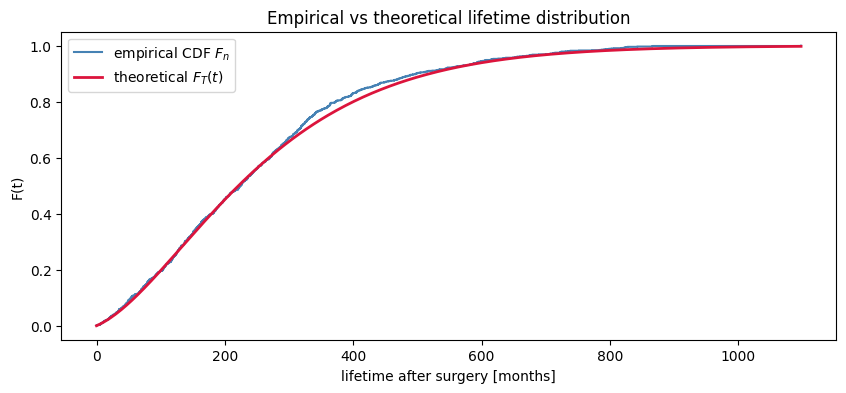

In [4]:
xs = np.sort(lifetimes)
ecdf = np.arange(1, N + 1) / N
grid = np.linspace(0, xs.max(), 400)

fig, ax = plt.subplots()
ax.step(xs, ecdf, where="post", color="steelblue", label="empirical CDF $F_n$")
ax.plot(grid, F_T(grid), color="crimson", lw=2, label="theoretical $F_T(t)$")
ax.set_xlabel("lifetime after surgery [months]")
ax.set_ylabel("F(t)")
ax.set_title("Empirical vs theoretical lifetime distribution")
ax.legend()
plt.show()

**Result.** $D_n = 0.039 <$ 95% critical $0.043$ ($p = 0.10 > 0.05$): the KS test does not reject the phase-type model, so the simulated lifetimes are consistent with the theoretical distribution.